## 注意力提示

注意力经济：注意力是稀缺资源，产生了以其为基础的商业模式。人类大脑需选择性处理信息。
生物学注意力：
非自主性提示：由物体突出性吸引注意力（如红杯子）。
自主性提：由主观意愿引导注意力（如想读书）。
*   **神经网络注意力机制（QKV框架）**：
    *   **查询 (Query)**：自主性提示。
    *   **键 (Key)**：感官输入的非自主性提示。
    *   **值 (Value)**：感官输入本身。
    *   通过将查询与键匹配，注意力机制实现对最相关值的加权选择，模拟人类注意力分配过程。

In [1]:
import torch

可视化权重

In [6]:
import matplotlib.pyplot as plt

def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    # Note: d2l.use_svg_display() is specific to the d2l library and is not used here.
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

在本例子中，仅当查询和键相同时，注意力权重为1，否则为0。

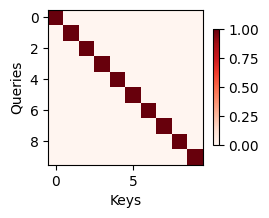

In [7]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')